# **Renkleri Filtreleme**

####** Bu derste şunları öğreneceğiz:**
1. Renge Göre Filtrelemek için HSV Renk Uzayı nasıl kullanılır

#### **HSV Renk Uzayını Hatırlayın**

<img src="HueValues.jpg" width="400">

- Hue: 0 - 179 Rengin türünü (kırmızı, yeşil, mavi vb.) ifade eder.
- Saturation: 0 - 255 Rengin ne kadar canlı veya soluk olduğunu belirtir.
- Value (Intensity): 0 - 255  Rengin parlaklığını belirler.

Dikkat edelim mavi renk 90 ile 135 arası


In [1]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

def imshow(title = "Image", image = None, size = 10):
    w, h = image.shape[0], image.shape[1]
    aspect_ratio = w/h
    plt.figure(figsize=(size * aspect_ratio,size))
    plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    plt.title(title)
    plt.show()

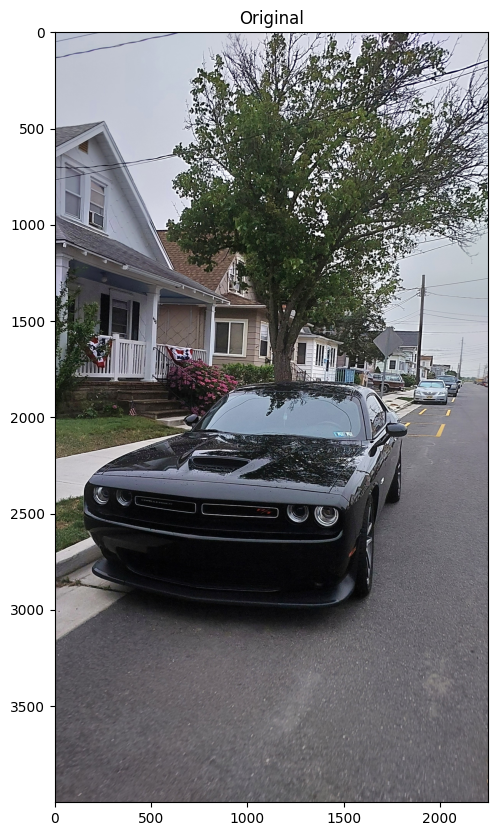

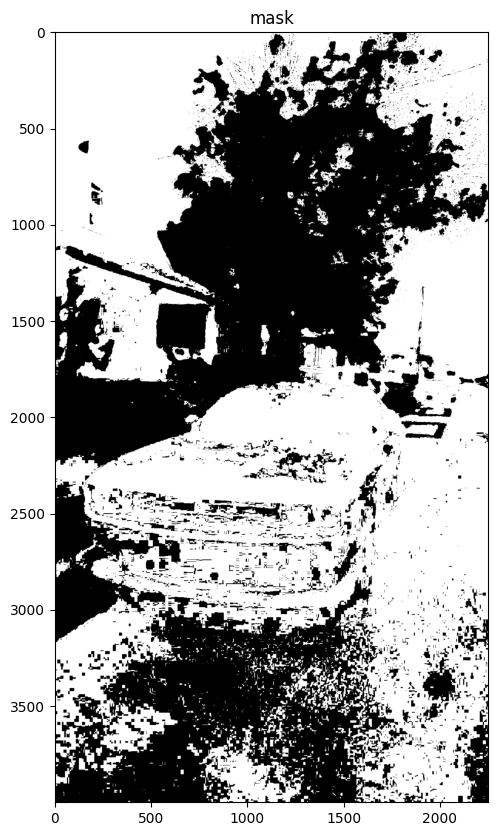

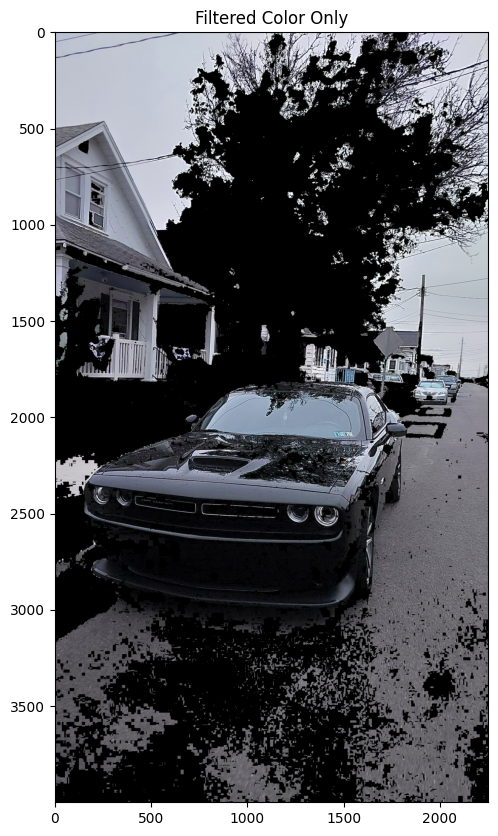

In [2]:
image = cv2.imread('../files/images/america29.jpg')

# HSV'de MAVİ renk aralığını tanımlayın
lower = np.array([90,0,0])
upper = np.array([135,255,255])

# Görüntüyü RBG/BGR'den HSV'ye dönüştürün, böylece kolayca filtreleyebiliriz
hsv_img = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)

# Yalnızca alt ve üst arasındaki değerleri yakalamak için inRange kullanalım
mask = cv2.inRange(hsv_img, lower, upper)
# Bir pikselin belirlenen alt ve üst sınırlar arasına düşüp düşmediğini kontrol eder.
# Sonuç olarak bir ikili (binary) maske üretir:
# Piksel aralık içindeyse 255 (beyaz)
# Piksel aralık dışındaysa 0 (siyah) olur.
# yani maskede istediğimiz renk olan bölgeler 255(beyaz) olur. diğer bölgeler 0(siyah)

# Maske ve orijinal çerçevemiz üzerinde Bitsel AND gerçekleştirin
res = cv2.bitwise_and(image, image, mask=mask)
#cv2.bitwise_and() fonksiyonu, iki görüntü üzerinde mantıksal AND işlemi uygular veya 
# bir görüntü ile bir maske kullanarak belirli bölgeleri seçer.
# dst = cv2.bitwise_and(src1, src2, mask=None)
# src1: İlk giriş görüntüsü
# src2: İkinci giriş görüntüsü (veya genellikle src1 ile aynı boyutta)
# mask: Opsiyonel. Sadece maskede 0 olmayan pikseller üzerinde işlem yapılır. 0 olanların tamamı 0 a dönüşür(siyah) 
# dst: Çıktı görüntüsü (aynı boyutta).

imshow('Original', image)  
imshow('mask', mask)
imshow('Filtered Color Only', res)

#### **Kırmızıyı filtreleme**


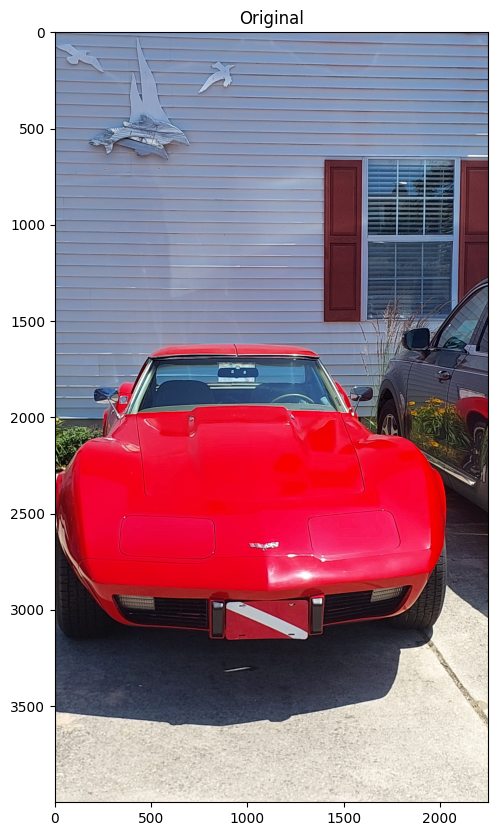

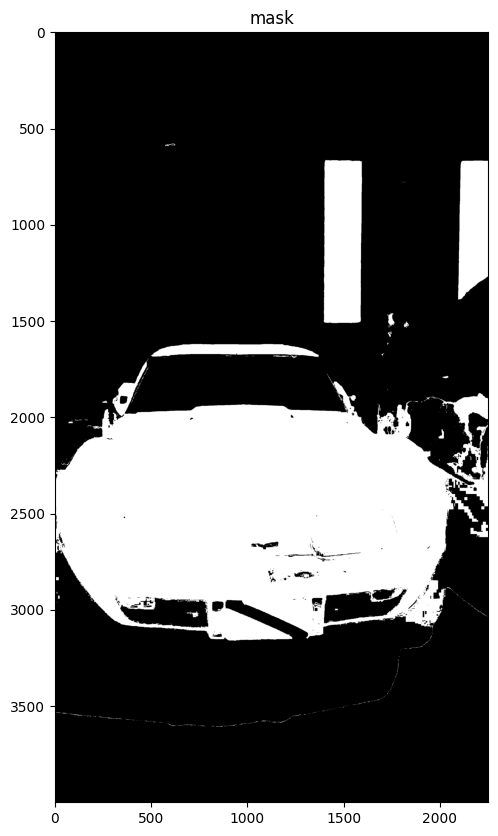

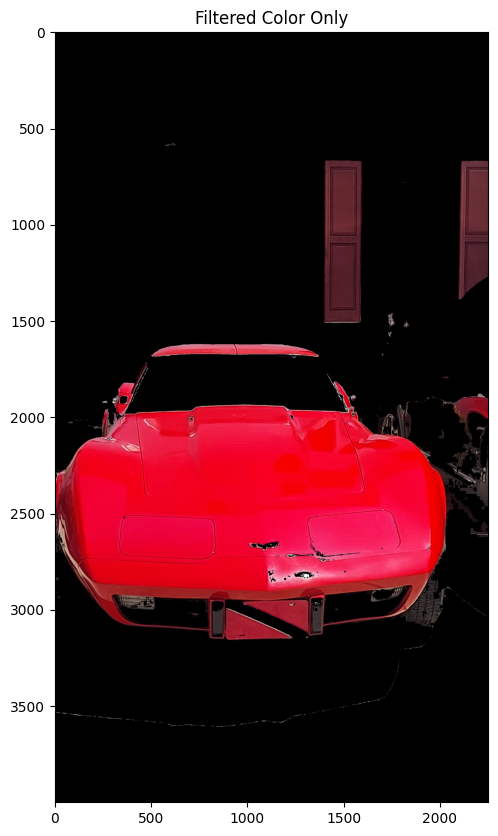

In [3]:
image = cv2.imread("../files/images/america30.jpg")

img_hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)

# alt maske (0-10)
lower_red = np.array([0,0,0])
upper_red = np.array([10,255,255])
mask0 = cv2.inRange(img_hsv, lower_red, upper_red)

# üst maske (170-180)
lower_red = np.array([170,0,0])
upper_red = np.array([180,255,255])
mask1 = cv2.inRange(img_hsv, lower_red, upper_red)

# maskeleri birleştir
mask = mask0+mask1

# Maske ve orijinal çerçevemiz üzerinde Bitsel AND gerçekleştirelim
res = cv2.bitwise_and(image, image, mask=mask)

imshow('Original', image)  
imshow('mask', mask)
imshow('Filtered Color Only', res)